**Connect to git repo + install requirements**

In [1]:
import os

#check if the repository folder already exists on the colab disk
if os.path.exists('/content/QML4EO-reproduction'):
    print("Repo found! Pulling latest changes from GitHub..")
    %cd /content/QML4EO-reproduction
    !git pull
else:
    print("Cloning repo for the first time..")
    %cd /content
    !git clone https://github.com/yeshapan/QML4EO-reproduction.git
    %cd QML4EO-reproduction

#install required dependencies
!pip install -r requirements.txt -q

Cloning repo for the first time..
/content
Cloning into 'QML4EO-reproduction'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 80 (delta 28), reused 68 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 6.99 MiB | 15.98 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/QML4EO-reproduction
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import torch
from src.baselines.cnn import set_seed, train_baseline
from src.utils.data_loader import get_eurosat_dataloaders
from src.models.hqcnn import HybridQCNN

#setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware utilized: {device}")

Hardware utilized: cuda


**Load Data**

In [3]:
#load data
train_loader, val_loader, classes = get_eurosat_dataloaders(
    data_dir="./data",
    batch_size=32,
    img_size=64
)

Downloading/Loading EuroSAT dataset into ./data...


100%|██████████| 94.3M/94.3M [00:02<00:00, 43.8MB/s]


Dataset loaded successfully!
Total images: 27000 | Training: 21600 | Validation: 5400
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


### **Experiment 2: Circuit Depth (Ansatz Layers)**

We have locked the bottleneck width at 4 qubits and we'll test the depth of the quantum circuit. Repeating the trainable operations (Ansatz layers) gives the model more parameters to tune. This increases quantum expressivity.

We'll test 2 and 3 layers to see if the added parameters improve performance or trigger Barren Plateaus (the quantum equivalent of vanishing gradients; where the loss landscape becomes entirely flat).

**Note:** Each depth configuration is tested across 3 random seeds for 15 epochs to ensure observations are statistically robust.

In [4]:
import numpy as np

#define the layer variations to test (skipping 1 since we have it in baseline!)
layer_configs = [2, 3]
qubits_locked = 4
EPOCHS = 15
SEEDS = [42, 100, 2026]

#dictionaries to store our final results and histories for plotting
depth_results = {}
depth_histories = {}

print("Starting Rigorous Circuit Depth Ablation Study..")

for layers in layer_configs:
    print(f"\n EXPERIMENT: {qubits_locked} QUBITS, {layers} ANSATZ LAYERS ")

    seed_accs = []
    total_params = 0

    for seed in SEEDS:
        print(f"\n Testing Seed {seed} ")
        set_seed(seed)

        #initialize fresh model for this config
        model = HybridQCNN(num_classes=len(classes), num_qubits=qubits_locked, num_layers=layers)
        model = model.to(device)

        if total_params == 0:
            total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f"Total Trainable Parameters: {total_params:,}")

        #run training
        history = train_baseline(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=EPOCHS,
            lr=0.001,
            device=device
        )

        seed_accs.append(history['val_acc'])

    #calculate statistics for this depth configuration
    acc_array = np.array(seed_accs)
    mean_acc = np.mean(acc_array, axis=0)
    std_acc = np.std(acc_array, axis=0)

    depth_histories[layers] = {'mean': mean_acc, 'std': std_acc}
    depth_results[f"{layers}_layers"] = {
        "params": total_params,
        "final_mean": mean_acc[-1],
        "final_std": std_acc[-1]
    }

print("\nCircuit Depth Study Complete!")
print("Summary of Results (Mean ± Std Dev):")
for config, metrics in depth_results.items():
    print(f"{config}: Parameters={metrics['params']}, Final Accuracy={metrics['final_mean']:.2f}% ± {metrics['final_std']:.2f}%")

Starting Rigorous Circuit Depth Ablation Study..

 EXPERIMENT: 4 QUBITS, 2 ANSATZ LAYERS 

 Testing Seed 42 
Total Trainable Parameters: 5,278


Epoch 1/15 [Train]: 100%|██████████| 675/675 [00:34<00:00, 19.74it/s, loss=1.7581]


Epoch 1 Summary -> Train Loss: 2.0706 | Val Accuracy: 32.65%


Epoch 2/15 [Train]: 100%|██████████| 675/675 [00:30<00:00, 22.09it/s, loss=1.5190]


Epoch 2 Summary -> Train Loss: 1.7626 | Val Accuracy: 34.85%


...

Epoch 13 Summary -> Train Loss: 0.7120 | Val Accuracy: 73.98%


Epoch 14/15 [Train]: 100%|██████████| 675/675 [00:35<00:00, 18.80it/s, loss=0.7614]


Epoch 14 Summary -> Train Loss: 0.6948 | Val Accuracy: 76.57%


Epoch 15/15 [Train]: 100%|██████████| 675/675 [00:36<00:00, 18.54it/s, loss=0.3950]


Epoch 15 Summary -> Train Loss: 0.6841 | Val Accuracy: 76.52%

Circuit Depth Study Complete!
Summary of Results (Mean ± Std Dev):
2_layers: Parameters=5278, Final Accuracy=69.69% ± 4.03%
3_layers: Parameters=5282, Final Accuracy=72.38% ± 3.02%


**Analysis: Quantum Expressivity and Rugged Landscapes**

This experiment tested whether increasing circuit depth improved feature extraction.

* The 3-layer ansatz achieved a mean accuracy of 72.38% ± 3.02%; outperforming the 1-layer baseline of ~66%. 
* This ~6% jump in validation accuracy required adding exactly 8 trainable parameters to the entire model.
* The validation accuracy visibly fluctuates and dips between certain epochs across all seeds.
* These dips do not indicate Barren Plateaus (as the model clearly continues to learn and improve over time).
* Instead, these fluctuations prove that deeper quantum circuits create highly rugged, non-convex loss landscapes.
* The classical optimizer occasionally overshoots narrow local minima in this complex space, causing temporary drops in performance.
* Adding layers linearly increases the computational penalty, dropping the simulation speed from ~26 it/s (1 layer) to ~18 it/s (3 layers).

**Visualization**

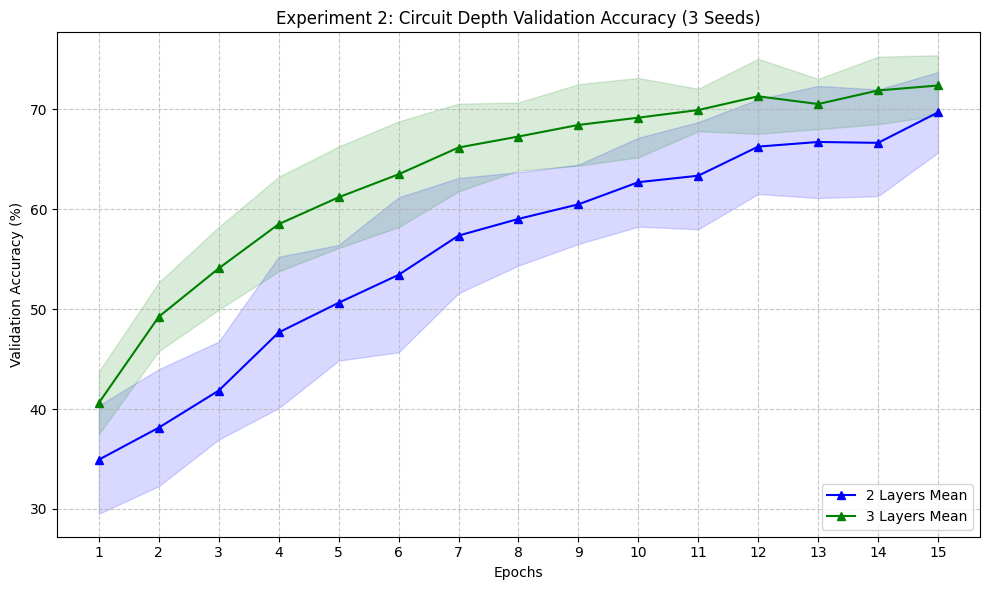

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
colors = {2: 'blue', 3: 'green'}
epochs_range = range(1, EPOCHS + 1)

for layers, data in depth_histories.items():
    mean_acc = data['mean']
    std_acc = data['std']

    plt.plot(epochs_range, mean_acc, label=f'{layers} Layers Mean', color=colors[layers], marker='^')
    plt.fill_between(
        epochs_range,
        mean_acc - std_acc,
        mean_acc + std_acc,
        color=colors[layers],
        alpha=0.15
    )

plt.title('Experiment 2: Circuit Depth Validation Accuracy (3 Seeds)')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy (%)')
plt.xticks(epochs_range)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()